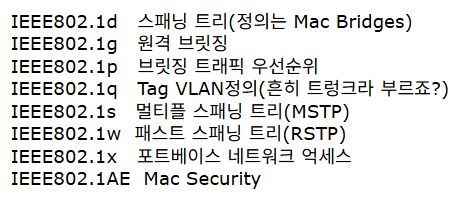

In [ ]:
STP ---> RSTP  ---> Pvst+
--------------                  : 동일 세그먼트(VLAN)
                    ----        : Per VLAN  : 각 세그먼트(VLAN)마다 별도 동작

In [ ]:
--------------- 회선 이중화 ----------------

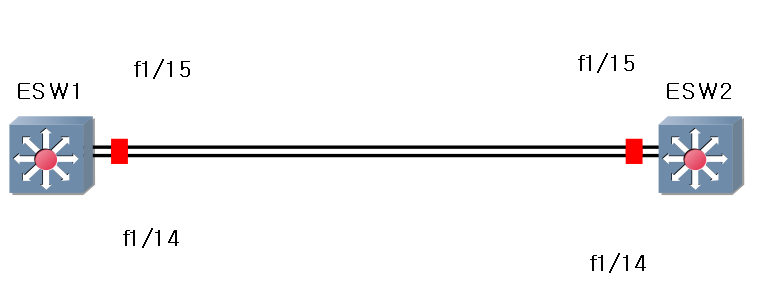

In [ ]:
STP : 802.1d   : Spanning Tree Protocol
         .1w   : RSTP : Rapid
    
     ==> Pvst+

In [ ]:
이중화 : HA : High Available : 고가용성 (지속 가능한)

In [ ]:
장비 ---> 회선 : 물리 / 논리
          장비 : FHRP(GLBP/VRRP/HSRP)
    SW --> L2 회선 : 회선이 이중화되면 브로드캐스트 스톰이 발생한다.
                     (BroadCast Storm) --> 루핑(Looping)
        해결책 : 특정 포트를 선정하여 BLK (블럭)
                                   --------- : BPDU (STP프로토콜) 패킷을 제외한
                                               모든 패킷을 차단한다.

In [ ]:
STP : 특정 포트(Root Port)로 패킷(BPDU)를 보내 다른 포트로 돌아온다면?  루핑발생
      가장 우선순위가 낮은 포트(Alternate Port)(대체 포트)로 선정한다.
                                                          (BLK)
        루핑이 발생하는 토폴로지를 끊어버린다.

In [ ]:
STP가 없을 때 문제점

In [ ]:
MAC 주소 불안정
BC Storm 발생 ---> 네트워크 동작 불능
중복된 UC 발생

====? 관리자가 컨트롤 불가

In [ ]:
루프 발생을 확인하는 명령어

In [ ]:
show process cpu

In [ ]:
ESW1#show process cpu
CPU utilization for five seconds: 1%/0%; one minute: 0%; five minutes: 0%
 PID Runtime(ms)   Invoked      uSecs   5Sec   1Min   5Min TTY Process
   1           0         5          0  0.00%  0.00%  0.00%   0 Chunk Manager
   2           0       110          0  0.00%  0.00%  0.00%   0 Load Meter
   3           0         1          0  0.00%  0.00%  0.00%   0 chkpt message ha
   4           0         1          0  0.00%  0.00%  0.00%   0 EDDRI_MAIN
   5        2268       145      15641  0.00%  0.43%  0.34%   0 Check heaps
   6           0         1          0  0.00%  0.00%  0.00%   0 Pool Manager
   7           0         2          0  0.00%  0.00%  0.00%   0 Timers
   8           0        10          0  0.00%  0.00%  0.00%   0 IPC Dynamic Cach
   9           0         1          0  0.00%  0.00%  0.00%   0 IPC Zone Manager
  10           0       539          0  0.00%  0.00%  0.00%   0 IPC Periodic Tim
  11           0       539          0  0.00%  0.00%  0.00%   0 IPC Deferred Por
  12           4         1       4000  0.00%  0.00%  0.00%   0 IPC Seat Manager
  13           0         1          0  0.00%  0.00%  0.00%   0 IPC BackPressure
  14           0         1          0  0.00%  0.00%  0.00%   0 OIR Handler
  15           0         1          0  0.00%  0.00%  0.00%   0 Crash writer
  16           0        20          0  0.00%  0.00%  0.00%   0 Environmental mo
  17           0        14          0  0.00%  0.00%  0.00%   0 ARP Input
  18           0         2          0  0.00%  0.00%  0.00%   0 ATM Idle Timer
  19           0         2          0  0.00%  0.00%  0.00%   0 AAA high-capacit
  20           0         1          0  0.00%  0.00%  0.00%   0 AAA_SERVER_DEADT
  21           0         1          0  0.00%  0.00%  0.00%   0 Policy Manager


In [ ]:
STP / VTP : 관리자가 활성화 시키거나 하지 않음 : 디폴트

In [ ]:
ESW1#sh spanning-tree brief

VLAN1
  Spanning tree enabled protocol ieee
  Root ID    Priority    32768
             Address     c401.2eec.0000
             This bridge is the root
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec

  Bridge ID  Priority    32768
             Address     c401.2eec.0000
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec
             Aging Time 300

Interface                                   Designated
Name                 Port ID Prio Cost  Sts Cost  Bridge ID            Port ID
-------------------- ------- ---- ----- --- ----- -------------------- -------
FastEthernet1/14     128.55   128    19 FWD     0 32768 c401.2eec.0000 128.55
FastEthernet1/15     128.56   128    19 FWD     0 32768 c401.2eec.0000 128.56

ESW1#


In [ ]:
FWD : 패킷 전송이 정상적으로 이루어지고 있는 상태

In [ ]:
ESW2#sh spanning-tree brief

VLAN1
  Spanning tree enabled protocol ieee
  Root ID    Priority    32768
             Address     c401.2eec.0000
             Cost        19
             Port        55 (FastEthernet1/14)
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec

  Bridge ID  Priority    32768
             Address     c402.0948.0000
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec
             Aging Time 300

Interface                                   Designated
Name                 Port ID Prio Cost  Sts Cost  Bridge ID            Port ID
-------------------- ------- ---- ----- --- ----- -------------------- -------
FastEthernet1/14     128.55   128    19 FWD     0 32768 c401.2eec.0000 128.55
FastEthernet1/15     128.56   128    19 BLK     0 32768 c401.2eec.0000 128.56

ESW2#


In [ ]:
BLK : BPDU만 통과시키고 나머지 패킷은 차단시키는 상태

In [ ]:
STP 동작 과정

In [ ]:
각 스위치는 자신의 Bridge ID를 생성

In [ ]:
우선순위값 (32768) + 스위치 MAC주소로 구성된다.

In [ ]:
ESW1 : 32768 + c401.2eec.0000

In [ ]:
ESW2 : 32768 + c402.0948.0000

In [ ]:
경합(내가 Root Bridge가 될꺼야) ---> 기준 : Bridge ID

In [ ]:
Root Bridge : 32768 + c401.2eec.0000

In [ ]:
 숫자가 작은 놈이 우선순위가 높다.  ===> 먼저 생산되면 MAC주소가 낮다.

In [ ]:
실전 : 우선순위 값 + 확장 시스템ID(VLAN 번호) +  스위치 MAC주소
        32768              1                   c401.2eec.0000

In [ ]:
       32769 + c401.2eec.0000

In [ ]:
Root Bridge 스위치가 선출되면 해당 스위치는 자신이 갖고 있는 모든 포트를

In [ ]:
Root Port로 지정한다.  ---> BPDU를 전달한다.

In [ ]:
BPDU를 수신하는 포트 DP(designate port)(지정포트)

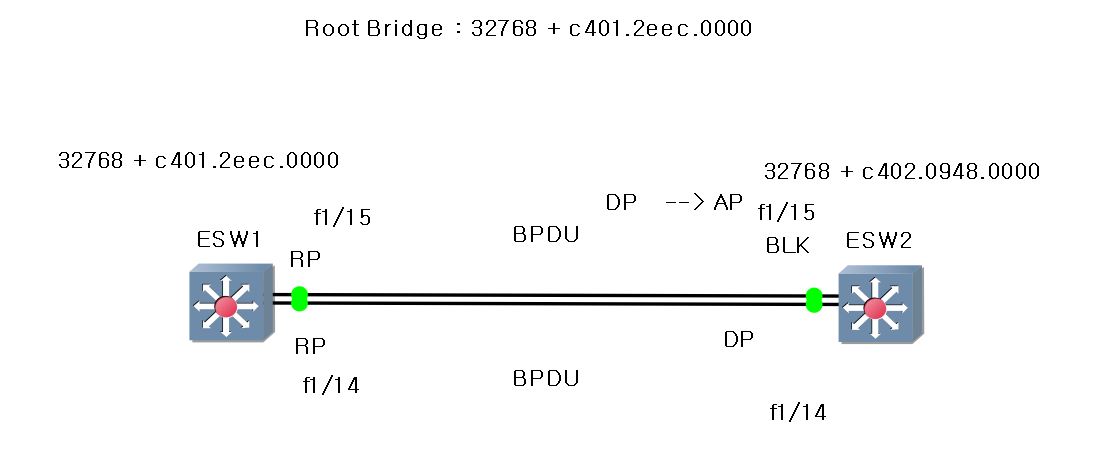

In [ ]:
ESW1은 루트 브릿지 스위치이기 때문에 포트를 다운 시키지 않고
ESW2는 루트 브릿지 스위치가 아니기 때문에 ESW2의 포트 중 하나의 포트를 AP 로 지정한다.

In [ ]:
Interface                                   Designated
Name                 Port ID Prio Cost  Sts Cost  Bridge ID            Port ID
-------------------- ------- ---- ----- --- ----- -------------------- -------
FastEthernet1/14     128.55   128    19 FWD     0 32768 c401.2eec.0000 128.55
FastEthernet1/15     128.56   128    19 BLK     0 32768 c401.2eec.0000 128.56

ESW2#

In [ ]:
0. Bridge ID를 비교 (현재 포트들은 같은 스위치에 있다.) 

In [ ]:
1. Cost를 확인 : 루트 브릿지 스위치로부터의 회선값(누적)
                                    100Mbps --> 19

In [ ]:
2. Priority

In [ ]:
3. Port ID : 기본값 128.XX
                       --- : 장비가 인식한 순서

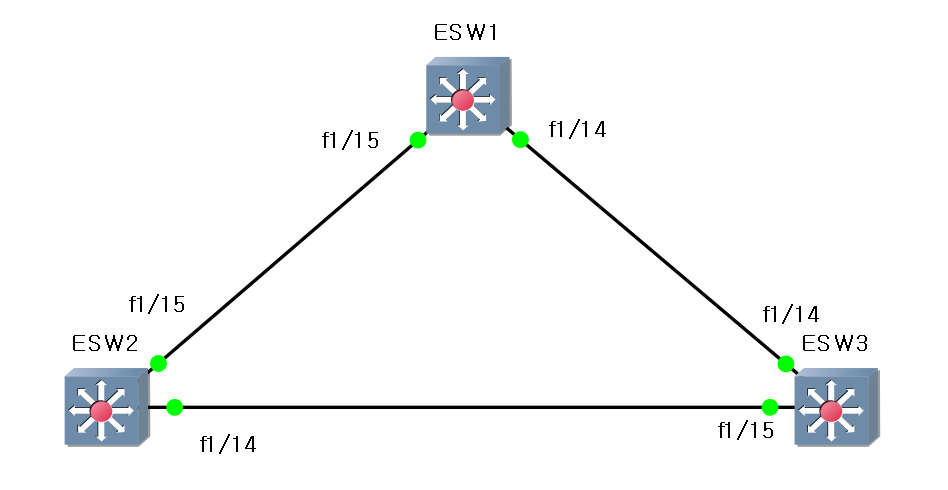

In [ ]:
ESW3 : sh ip int bri

In [ ]:
FastEthernet1/14           unassigned      YES unset  up                    up              
FastEthernet1/15           unassigned      YES unset  up                    up              
Vlan1                      unassigned      YES NVRAM  administratively down down            
ESW3#


In [ ]:
ESW3#sh spanning-tree bri

VLAN1
  Spanning tree enabled protocol ieee
  Root ID    Priority    32768
             Address     c401.341c.0000
             Cost        19
             Port        55 (FastEthernet1/14)
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec

  Bridge ID  Priority    32768
             Address     c403.04f8.0000
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec
             Aging Time 300

Interface                                   Designated
Name                 Port ID Prio Cost  Sts Cost  Bridge ID            Port ID
-------------------- ------- ---- ----- --- ----- -------------------- -------
FastEthernet1/14     128.55   128    19 FWD     0 32768 c401.341c.0000 128.55
FastEthernet1/15     128.56   128    19 BLK    19 32768 c402.43e4.0000 128.55

ESW3#


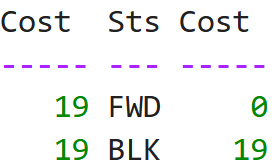

In [ ]:
루트 스위치로부터의 거리 : 앞의 Cost : 스위치 자신
                         뒤의 Cost : 전달한 스위치의 Cost

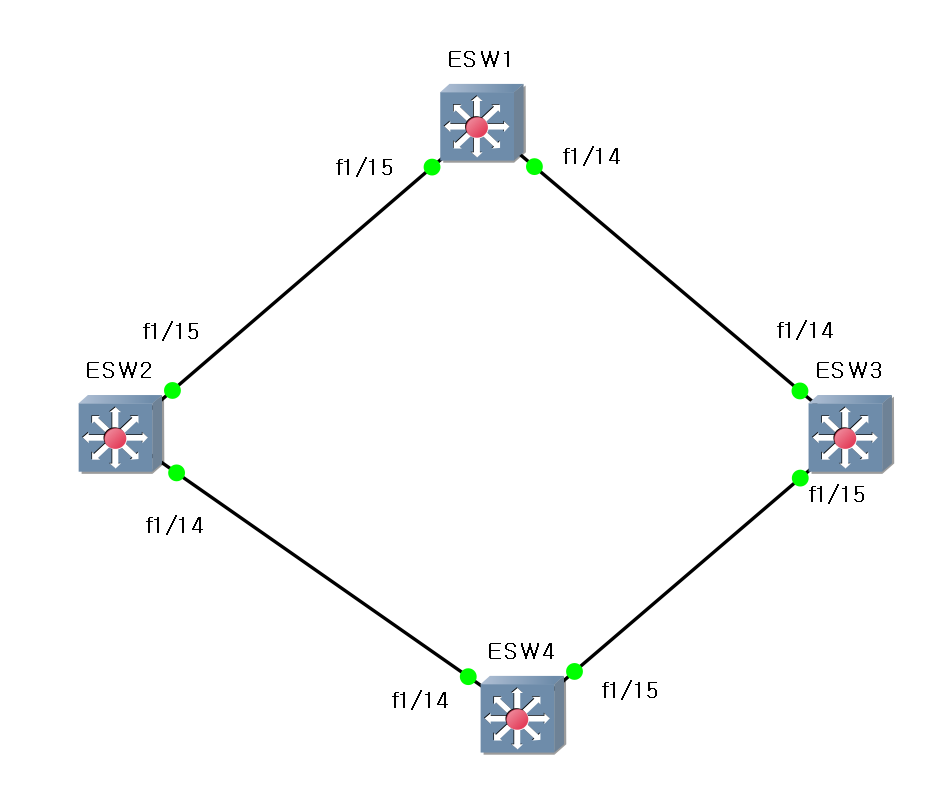

In [ ]:
시나리오 조정 : ESW3가 인터넷망과 연결되어 있는 경우

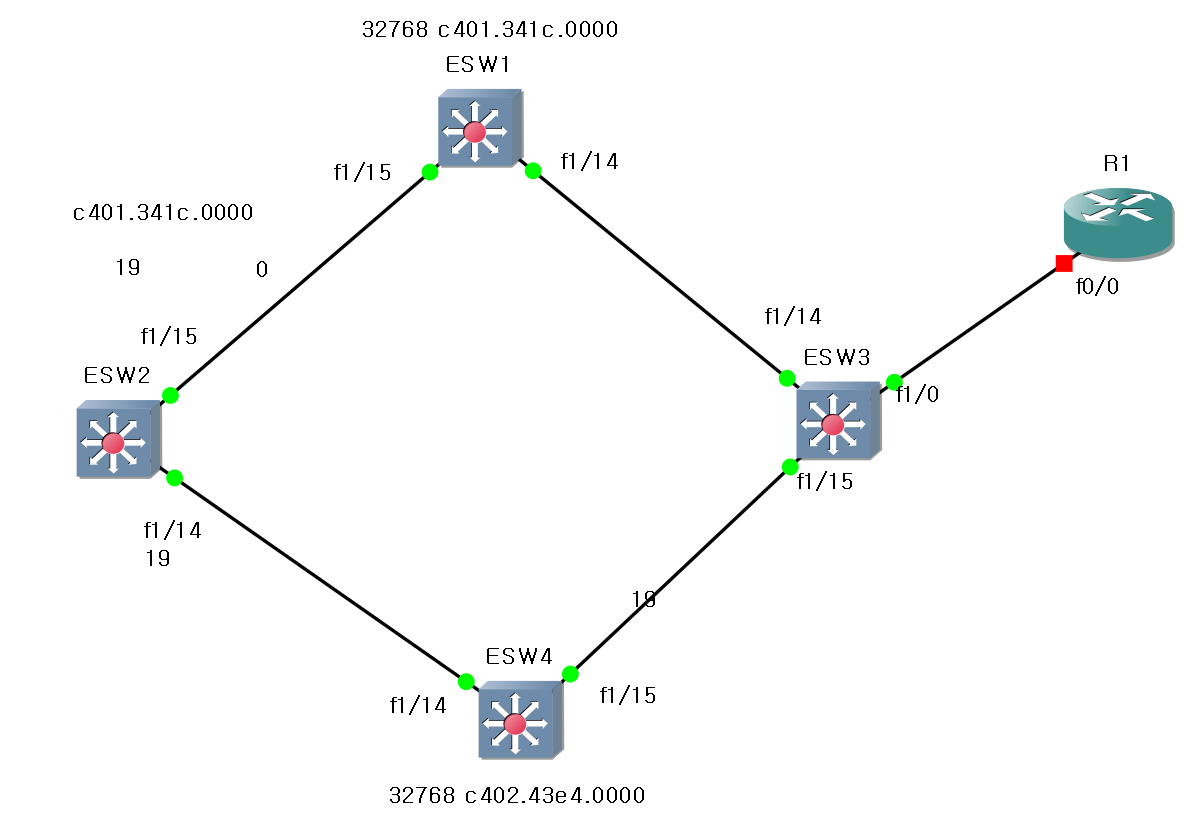

In [ ]:
목표 : ESW3가 루트 브릿지 스위치로 선출되어야 한다.

In [ ]:
STP의 조정 : 우선순위값을 조정한다.

In [ ]:
현재 모든 스위치의 우선순위값 : 32768

In [ ]:
조정 단위 : 4096

In [ ]:
ESW3(config)#spanning-tree vlan 1 priority 4096

In [ ]:
ESW3#sh spanning-tree bri

VLAN1
  Spanning tree enabled protocol ieee
  Root ID    Priority    4096
             Address     c403.04f8.0000
             This bridge is the root
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec

  Bridge ID  Priority    4096
             Address     c403.04f8.0000
             Hello Time   2 sec  Max Age 20 sec  Forward Delay 15 sec
             Aging Time 300

Interface                                   Designated
Name                 Port ID Prio Cost  Sts Cost  Bridge ID            Port ID
-------------------- ------- ---- ----- --- ----- -------------------- -------
FastEthernet1/14     128.55   128    19 FWD     0  4096 c403.04f8.0000 128.55
FastEthernet1/15     128.56   128    19 FWD     0  4096 c403.04f8.0000 128.56

ESW3#

In [ ]:
ESW3 <-- 루트 브릿지 스위치로 선정되었다.

In [ ]:
priority값을 변경하면 즉시 루트 브릿지 선정을 다시한다.

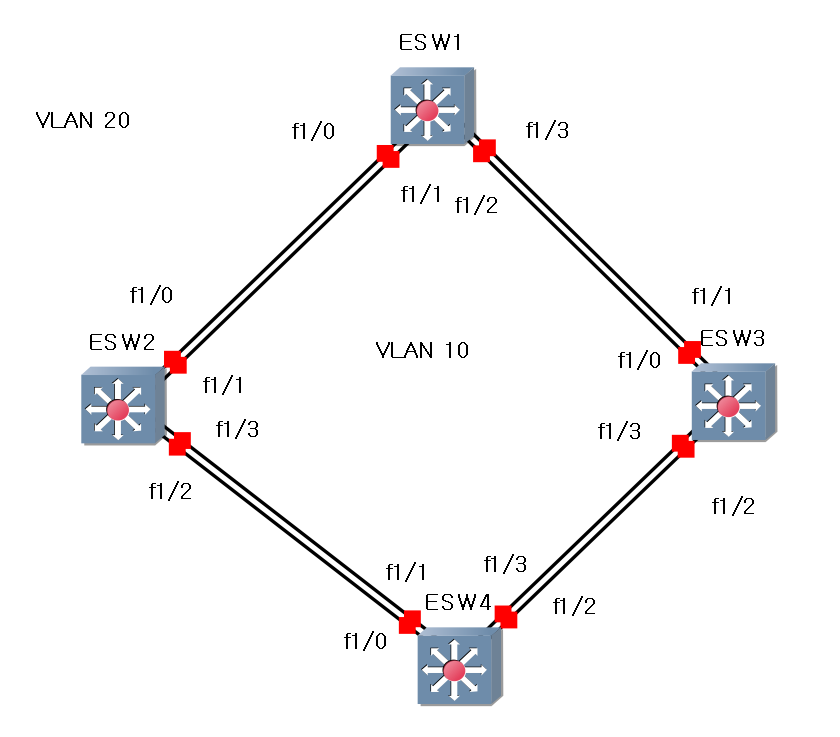

In [ ]:
조건 
평소에 VLAN10은 ESW2 스위치를 통해 통신
평소에 VLAN20은 ESW3 스위치를 통해 통신

In [ ]:
ESW1
conf t
span vlan 10 pri 4096
span vlan 20 pri 4096

In [ ]:
ESW3
conf t
span vlan20 8192

In [ ]:
STP 동작 과정 (5단계) : 50초

In [ ]:
대기(Disalbe) --> 청취(LIS) --> 학습(LRN) --> 전달(FWD) ---> 블럭(BLK)
    ---            20초

In [ ]:
RSTP 동작 과정 (3단계) : 30초

In [ ]:
블럭(BLK) --> 학습(LRN) --> 전달(FWD) 